In [1]:
print("test")

test


In [2]:
# uv 프로젝트 환경이 있으면 uv sync로 의존성 설치 (권장)
!pip install numpy pandas matplotlib seaborn scipy scikit-learn statsmodels pingouin scikit_posthocs xgboost unidecode geopandas -q
print("pip 설치 완료!")

pip 설치 완료!



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
!c:\Users\82105\Desktop\it-s_advanced_project\.venv\Scripts\python.exe -m ensurepip
!c:\Users\82105\Desktop\it-s_advanced_project\.venv\Scripts\python.exe -m pip install unidecode
!c:\Users\82105\Desktop\it-s_advanced_project\.venv\Scripts\python.exe -m pip install geopandas

Looking in links: c:\Users\82105\AppData\Local\Temp\tmpc83teeav



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: c:\Users\82105\Desktop\it-s_advanced_project\.venv\Scripts\python.exe -m pip install --upgrade pip


In [3]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings
from unidecode import unidecode
import geopandas as gpd

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)



라이브러리 로드 완료!
한글 폰트 설정 완료!


In [4]:
import sys
print(sys.executable)

c:\Users\82105\AppData\Local\Programs\Python\Python312\python.exe


In [5]:
import os
os.chdir("C:/Users/82105/Desktop/it-s_advanced_project")

In [64]:
df_order_items = pd.read_csv('works/data/olist_order_items_dataset.csv')
df_products = pd.read_csv('works/data/olist_products_dataset.csv')
df_sellers = pd.read_csv('works/data/olist_sellers_dataset.csv')
df_geolocation = pd.read_csv('works/data/olist_geolocation_dataset.csv')

In [7]:
df_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


In [8]:
df_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [9]:
df_geolocation.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 38.2 MB


In [11]:
df_geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [65]:
print(df_geolocation['geolocation_zip_code_prefix'].duplicated().sum())

981148


In [66]:
df_geolocation[df_geolocation['geolocation_zip_code_prefix'].duplicated(keep=False)]['geolocation_zip_code_prefix'].nunique()

17972

In [67]:
dup_zip = df_geolocation['geolocation_zip_code_prefix'].duplicated(keep = False)
df_dup = df_geolocation[dup_zip][['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']].sort_values('geolocation_zip_code_prefix')
df_dup.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
429,1001,-23.550498,-46.634338
519,1001,-23.551337,-46.634027
575,1001,-23.549779,-46.633957
596,1001,-23.550498,-46.634338
206,1001,-23.550498,-46.634338


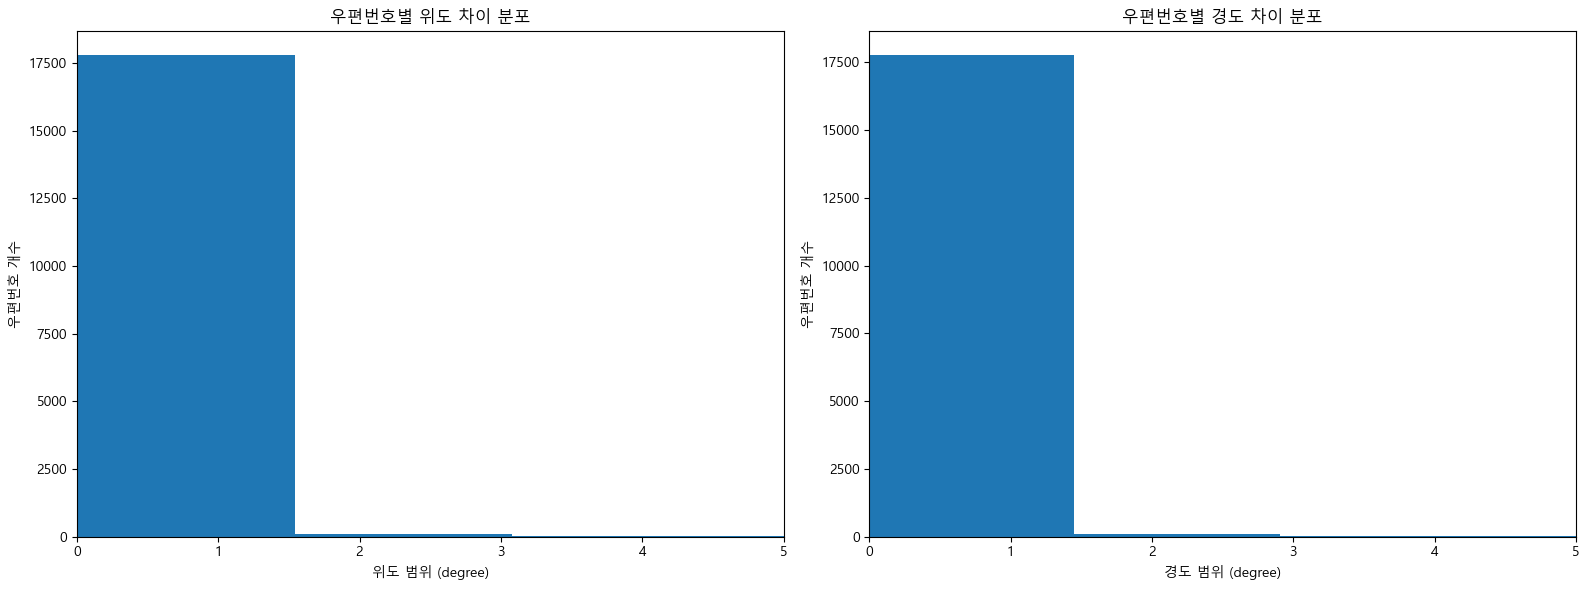

In [68]:

df_range = df_dup.groupby('geolocation_zip_code_prefix').agg(
    lat_range=('geolocation_lat', lambda x: x.max() - x.min()),
    lng_range=('geolocation_lng', lambda x: x.max() - x.min())
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(df_range['lat_range'], bins=50)
axes[0].set_title('우편번호별 위도 차이 분포')
axes[0].set_xlabel('위도 범위 (degree)')
axes[0].set_ylabel('우편번호 개수')
axes[0].set_xlim(0, 5)

axes[1].hist(df_range['lng_range'], bins=50)
axes[1].set_title('우편번호별 경도 차이 분포')
axes[1].set_xlabel('경도 범위 (degree)')
axes[1].set_ylabel('우편번호 개수')
axes[1].set_xlim(0, 5)

plt.tight_layout()
plt.show()

In [69]:
print(df_range[df_range['lat_range'] > 10].shape[0])  # 위도 차이 10도 이상

52


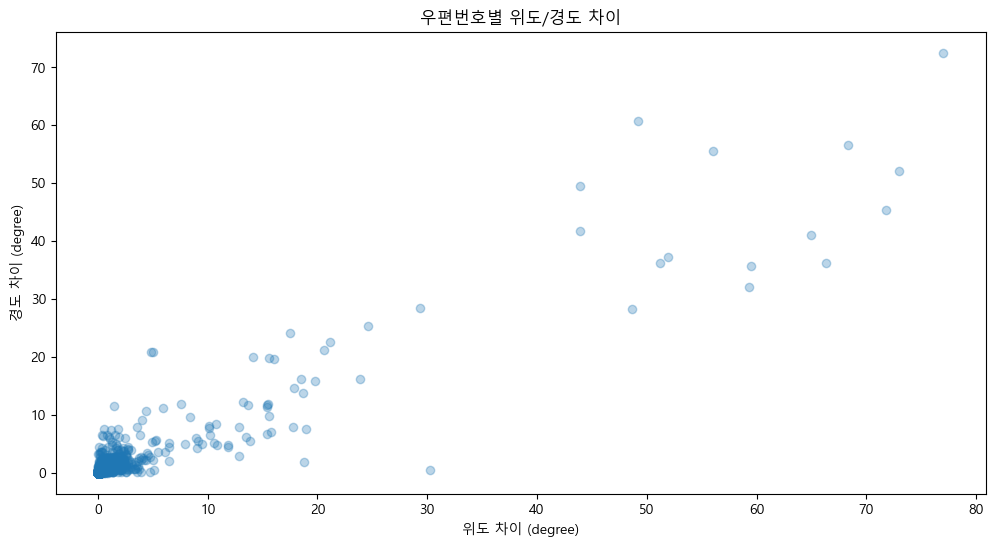

In [70]:
plt.scatter(df_range['lat_range'], df_range['lng_range'], alpha=0.3)
plt.xlabel('위도 차이 (degree)')
plt.ylabel('경도 차이 (degree)')
plt.title('우편번호별 위도/경도 차이')
plt.show()

In [71]:
print(df_geolocation['geolocation_lng'].max())
print(df_geolocation['geolocation_lng'].min())
print(df_geolocation['geolocation_lat'].max())
print(df_geolocation['geolocation_lat'].min())

121.10539381057764
-101.46676644931476
45.06593318269697
-36.6053744107061


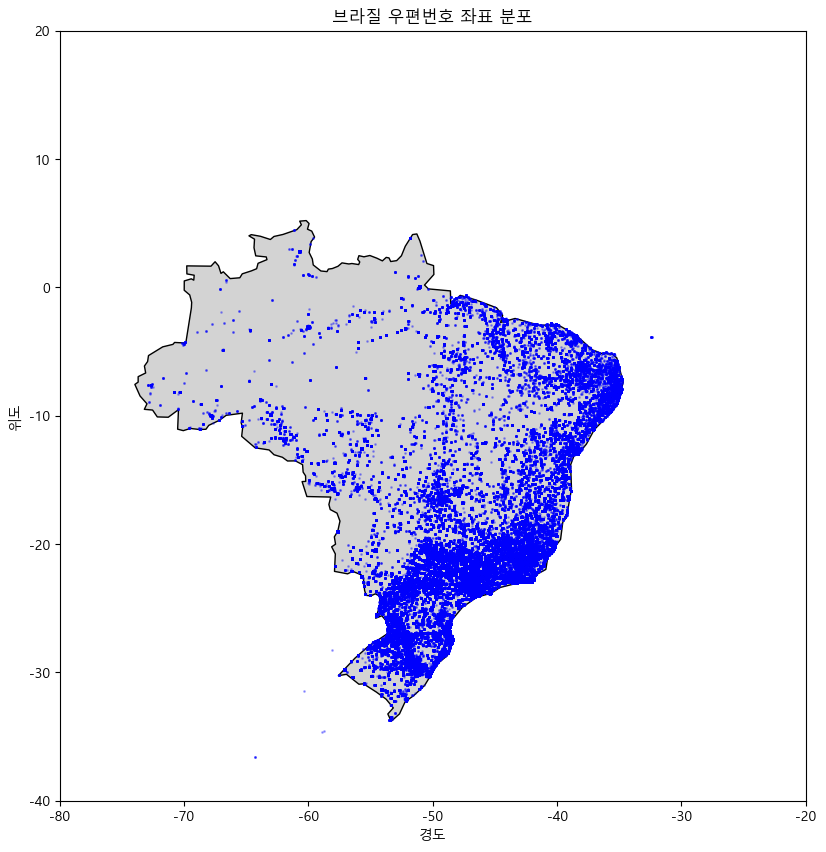

In [72]:
# URL에서 직접 브라질 지도 불러오기
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
brazil = world[world['NAME'] == 'Brazil']

fig, ax = plt.subplots(figsize=(12, 10))

brazil.plot(ax=ax, color='lightgrey', edgecolor='black')

ax.scatter(df_geolocation['geolocation_lng'], df_geolocation['geolocation_lat'],
           s=1, alpha=0.3, color='blue')

ax.set_xlim(-80, -20) #경도 비율 조절
ax.set_ylim(-40, 20) #위도 비율 조절

ax.set_title('브라질 우편번호 좌표 분포')
ax.set_xlabel('경도')
ax.set_ylabel('위도')
plt.show()

In [73]:
#위도(lat) -34~6, 경도(lng) -74.5~-32

df_geolocation = df_geolocation[
    (df_geolocation['geolocation_lng'] < -32) &
    (df_geolocation['geolocation_lng'] > -74.5) &
    (df_geolocation['geolocation_lat'] < 6) &
    (df_geolocation['geolocation_lat'] > -34)
]

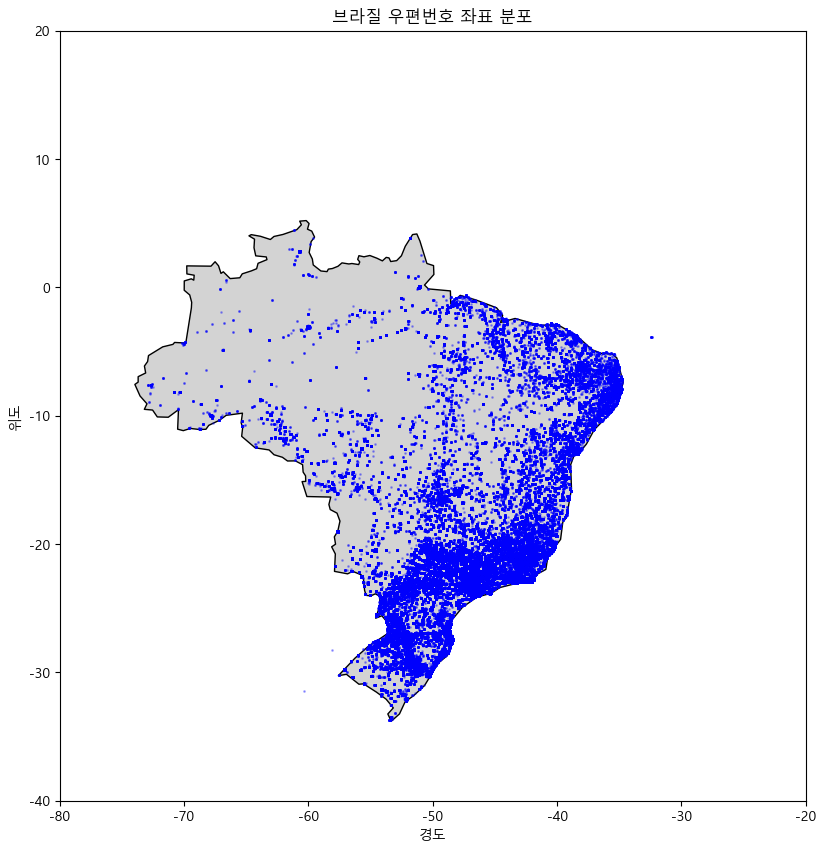

In [74]:

fig, ax = plt.subplots(figsize=(12, 10))

brazil.plot(ax=ax, color='lightgrey', edgecolor='black')

ax.scatter(df_geolocation['geolocation_lng'], df_geolocation['geolocation_lat'],
           s=1, alpha=0.3, color='blue')

ax.set_xlim(-80, -20) #경도 비율 조절
ax.set_ylim(-40, 20) #위도 비율 조절

ax.set_title('브라질 우편번호 좌표 분포')
ax.set_xlabel('경도')
ax.set_ylabel('위도')
plt.show()

In [75]:
# -32보다 큰 경도 값 확인
print(df_geolocation[df_geolocation['geolocation_lng'] > -32]['geolocation_lng'])

Series([], Name: geolocation_lng, dtype: float64)


In [76]:
print(df_geolocation.shape)

(1000132, 5)


In [77]:
df_geolocation = df_geolocation.groupby('geolocation_zip_code_prefix').filter(
    lambda x: (x['geolocation_lat'].max() - x['geolocation_lat'].min() < 1.5) &
              (x['geolocation_lng'].max() - x['geolocation_lng'].min() < 1.5)
)


In [80]:
print(df_geolocation.shape)

(988050, 5)


In [81]:
# 필터링 후 df_dup 다시 계산
dup_zip2 = df_geolocation['geolocation_zip_code_prefix'].duplicated(keep=False)
df_dup2 = df_geolocation[dup_zip2][['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']]

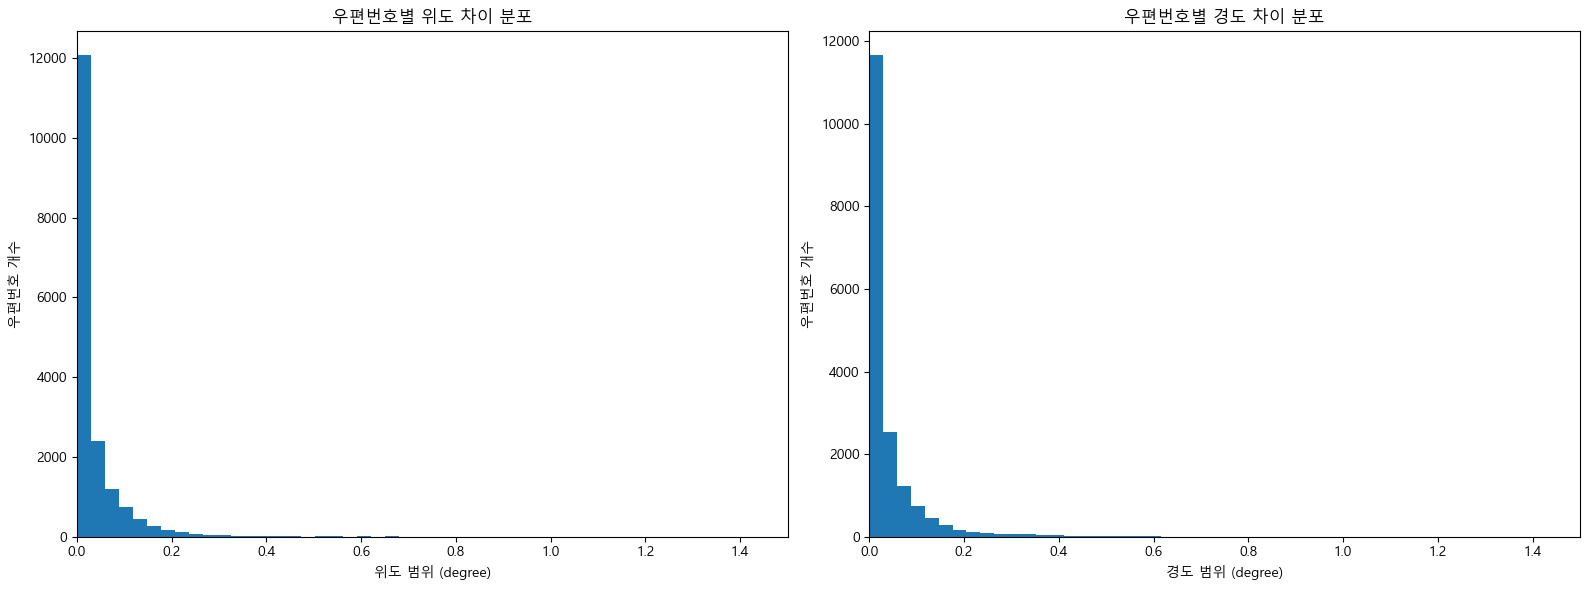

In [83]:
df_range2 = df_dup2.groupby('geolocation_zip_code_prefix').agg(
    lat_range=('geolocation_lat', lambda x: x.max() - x.min()),
    lng_range=('geolocation_lng', lambda x: x.max() - x.min())
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(df_range2['lat_range'], bins=50)
axes[0].set_title('우편번호별 위도 차이 분포')
axes[0].set_xlabel('위도 범위 (degree)')
axes[0].set_ylabel('우편번호 개수')
axes[0].set_xlim(0, 1.5)

axes[1].hist(df_range2['lng_range'], bins=50)
axes[1].set_title('우편번호별 경도 차이 분포')
axes[1].set_xlabel('경도 범위 (degree)')
axes[1].set_ylabel('우편번호 개수')
axes[1].set_xlim(0, 1.5)

plt.tight_layout()
plt.show()

In [ ]:
#print(df_geolocation['geolocation_city'].drop_duplicates().sort_values())
print(df_geolocation['geolocation_city'].unique())

<StringArray>
[            'sao paulo',             'são paulo', 'sao bernardo do campo',
               'jundiaí',       'taboão da serra',              'sãopaulo',
                    'sp',            'sa£o paulo',   'sao jose dos campos',
                'osasco',
 ...
       'ipiranga do sul',          'vila langaro',               'ciriaco',
      'floriano peixoto',              'erebango',                'ibiaçá',
  'santa cecilia do sul',               'ciríaco',               'estação',
          'vila lângaro']
Length: 8011, dtype: str


In [ ]:
df_geolocation['geolocation_city'] = df_geolocation['geolocation_city'].str.lower().apply(unidecode)
print(df_geolocation['geolocation_city'].unique())

print(df_geolocation[df_geolocation['geolocation_city'].apply(lambda x: not isinstance(x, str))]['geolocation_city'].unique())

<StringArray>
[            'sao paulo', 'sao bernardo do campo',               'jundiai',
       'taboao da serra',              'saopaulo',                    'sp',
           'saPSo paulo',   'sao jose dos campos',                'osasco',
           'carapicuiba',
 ...
            'agua santa',             'muliterno',               'estacao',
               'charrua',       'ipiranga do sul',          'vila langaro',
               'ciriaco',      'floriano peixoto',              'erebango',
  'santa cecilia do sul']
Length: 5969, dtype: str
<StringArray>
[]
Length: 0, dtype: str


In [ ]:
df_geolocation['geolocation_city'] = df_geolocation['geolocation_city'].str.lower().apply(unidecode).strip()

AttributeError: 'Series' object has no attribute 'strip'

In [ ]:
print(df_geolocation['geolocation_state'].drop_duplicates().sort_values())
df_geolocation['geolocation_state'] = df_geolocation['geolocation_state'].str.upper().str.strip()

778186    AC
724566    AL
775108    AM
774255    AP
668525    BA
739326    CE
779484    DF
525441    ES
791619    GO
755549    MA
542189    MG
831694    MS
819662    MT
763402    PA
728749    PB
708133    PE
751000    PI
842126    PR
404270    RJ
714435    RN
812609    RO
777226    RR
938313    RS
899986    SC
704570    SE
0         SP
816086    TO
Name: geolocation_state, dtype: str


In [ ]:
print(df_products['product_category_name'].isna().sum())
print(df_products['product_name_lenght'].isna().sum())
print(df_products['product_description_lenght'].isna().sum())
print(df_products['product_photos_qty'].isna().sum())
print(df_products['product_weight_g'].isna().sum())
print(df_products['product_length_cm'].isna().sum())
print(df_products['product_height_cm'].isna().sum())
print(df_products['product_width_cm'].isna().sum())
print(df_products['product_id'].isna().sum())

610
610
610
610
2
2
2
2
0


In [ ]:
df_products = df_products.dropna(subset=['product_weight_g'])
df_products = df_products.dropna(subset=['product_length_cm'])
df_products = df_products.dropna(subset=['product_height_cm'])
df_products = df_products.dropna(subset=['product_width_cm'])

print(df_products['product_weight_g'].isna().sum())
print(df_products['product_length_cm'].isna().sum())
print(df_products['product_height_cm'].isna().sum())
print(df_products['product_width_cm'].isna().sum())

0
0
0
0


In [ ]:
df_products.sort_values(['product_weight_g'])
#0g 4개 -> category: cama_mesa_banho(침구, 욕실 용품이라 매트 등도 포함 이상치 아님으로 판단)
#회의 결과, 이상치로 판단


df_products = df_products[df_products['product_weight_g'] != 0]

In [ ]:
df_products.shape
#32949개의 행 데이터셋에서 결측치 610개 -> 1.8% 정도로 drop해도 상관없지만 "unknown"으로 채우기

(32949, 9)

In [ ]:
df_products['product_category_name'] = df_products['product_category_name'].fillna("unknown")